## Video Frame Tracking - (SIFT) Pipeline


##### 1. Find (Keypoints) Local Features - (DoG)
- Build: Gaussian Pyramid
- Calculate: (Dog) Difference of Gaussians
- Find: ____ existing across multiple frames

In [ ]:
# Setup 

# Essential Libraries
import cv2
import matplotlib.pyplot as plt

# Define | Data Directory
image_dir = "C:/Users/Zed/Desktop/AIML331/Assignment 2/AIML331_A2_Data/data/"

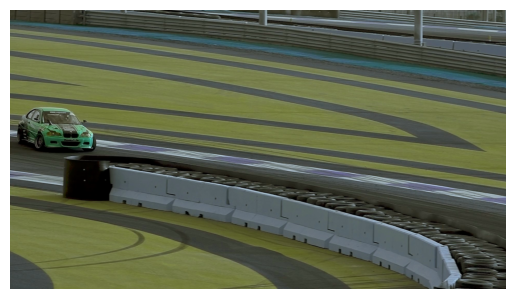

In [ ]:
# Image Preparation -> Analysis

# Inital View | Original Image State
img = cv2.imread(image_dir + 'frame_0.jpg', 1)      # 1 for (BGR Format) (Blue, Green, Red)  
#img = cv2.imread('frame_0', 1)                     # If images are within the same directory | USE THIS INSTEAD
height, width, channels = img.shape                 # Image Dimensions
plt.imshow(img)
plt.axis('off')
plt.show()

# References 1

##### References 1
- How to iterate through images in a folder Python?
    - GeeksforGeeks. (2021, November 26). How to iterate through images in a folder Python? GeeksforGeeks. https://www.geeksforgeeks.org/python/how-to-iterate-through-images-in-a-folder-python/

‌

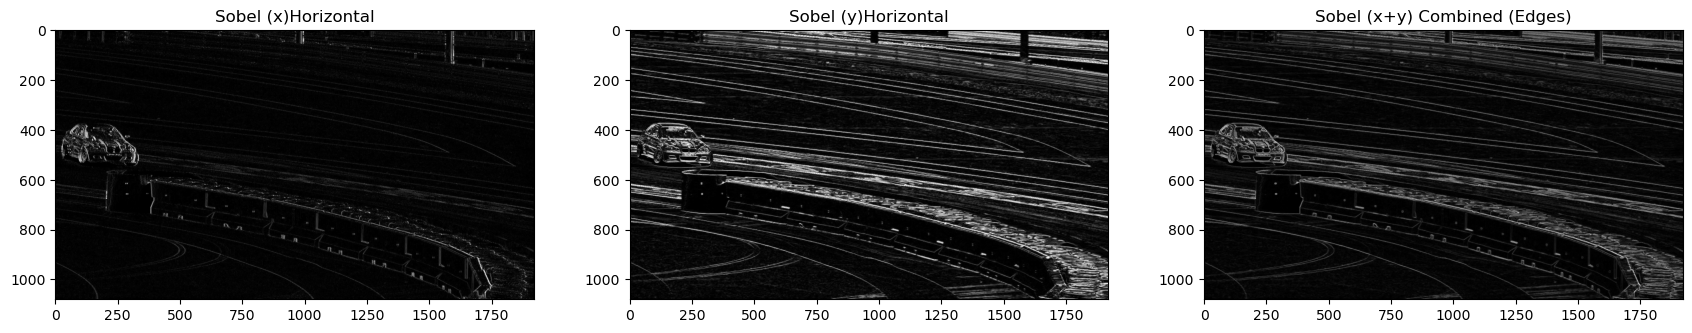

In [ ]:
# Image Preparation | Image Stage 2 | Grayscale Conversion | 

gray_var = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)    # Edge Detection Algs. | Intensity Gradients | Needs grayscale imgs.

# Apply Sobel Operator ( (x)Horizontal  + (y)Vertical Directions )
sobel_x = cv2.Sobel(gray_var, cv2.CV_64F, 1, 0, ksize=3)    # X gradient
sobel_y = cv2.Sobel(gray_var, cv2.CV_64F, 0, 1, ksize=3)    # Y gradient

# Convert to Absolute Values
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine gradients
sobel_comb = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

# Display Results
plt.figure(figsize=(21,21))
plt.subplot(1,3,1), plt.imshow(sobel_x, cmap='gray'), plt.title("Sobel (x)Horizontal")
plt.subplot(1,3,2), plt.imshow(sobel_y, cmap='gray'), plt.title("Sobel (y)Horizontal")
plt.subplot(1,3,3), plt.imshow(sobel_comb, cmap='gray'), plt.title("Sobel (x+y) Combined (Edges)")
plt.show()


##### References 2
- **** Image Gradient and Edge Detection*****
    - tutorial_week4.ipynb
‌

##### 2. Localisation
- Find: Local extrema
- Prune: "bad" points (Stable - (x, y, σ) coordinates)

##### 3. Orientation
- Create: Histogram (Local gradients)
- Find: Dominant peak
- Assign: "Up" direction -> keypoint | Give rotation invariance

## Keypoint Matching (Finding Correspondences)

##### 4. Describe their patterns (SIFT Descriptors)
- Build: 4x4 Grid of orientation Histograms
    - 16 cells x 8 bins
- Create: 128-dimensional vector -> uniquely identifies each patch
- GOAL: Descriptor - Invariant to translation, scale, rotation, and lighting!

##### 3. Correspondence Matching (Pairwise Matching)

##### 4. Outlier Removal (RANSAC)

## Keypoint Visualization

##### 1. Indicate Positions - Successfully Tracked Points -> Video Frames
- Overlay connecting line (previous position -> current position) across successive frames

## References

- Puzzle Piece Awarness: SIFT Outline | w4_lec02_Local Feature_DoG and SIFT.pdf
- w5_Tutorial.pdf


- Online APA 7 | Website Citator
    - https://www.mybib.com/tools/apa-citation-generator